## Demo

In [1]:
import SimpleITK as sitk
import matplotlib.pyplot as plt
import torch
import numpy as np
from synthnormaug import SyntheticGMMAugmentation

### load an example of a z-score normalized image, WMH mask and Synthseg image

In [2]:
flair = torch.from_numpy(sitk.GetArrayFromImage(sitk.ReadImage("example_flair.nii.gz")))
wmh = torch.from_numpy(sitk.GetArrayFromImage(sitk.ReadImage("example_wmh.nii.gz")))
synthseg = torch.from_numpy(sitk.GetArrayFromImage(sitk.ReadImage("example_synthseg.nii.gz")))
mask = torch.from_numpy(sitk.GetArrayFromImage(sitk.ReadImage("example_brainmask.nii.gz")))

In [3]:
# create object suitable for MONAI augmentations
data = {'FLAIR':flair.unsqueeze(0), 'label':wmh.unsqueeze(0), 'synthseg':synthseg.unsqueeze(0), 'brainmask':mask.unsqueeze(0)}

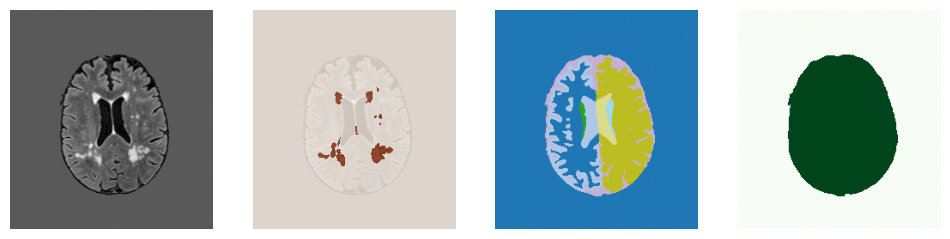

In [4]:
islice = 140
fig, axs = plt.subplots(1, 4, figsize=(12, 3))

axs[0].imshow(flair[islice], origin='lower', cmap='gray')
axs[1].imshow(flair[islice], origin='lower', cmap='gray')
axs[1].imshow(wmh[islice], origin='lower', cmap='Oranges', alpha=0.8)
axs[2].imshow(synthseg[islice], origin='lower', cmap='tab20')
axs[3].imshow(mask[islice], origin='lower', cmap='Greens')
for ax in axs:
    ax.axis('off')

### example SynthNorm augmentation

In [5]:
from synthnormaug.synthetic_intensity_augmentation import SyntheticGMMAugmentation

In [6]:
gmm_weight_path = "synthnormaug/synthetic_intensity_augmentation/gmm_params"
synthnorm = SyntheticGMMAugmentation(
    mean_z_temperature_cap=10,
    std_z_temperature_cap=10,
    std_weighting=0.5,
    keys=['FLAIR'],
    wmh_mask='label',
    gmm_weight_path=gmm_weight_path
)

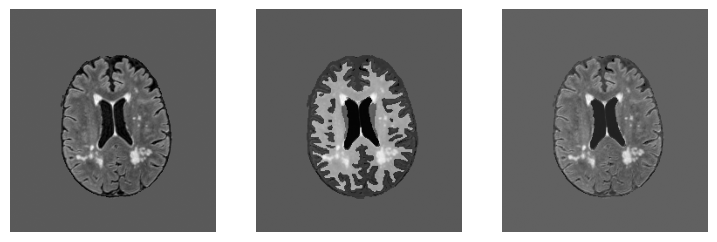

In [21]:
example_1 = synthnorm(data)
example_2 = synthnorm(data)

fig, axs = plt.subplots(1, 3, figsize=(9, 3))

axs[0].imshow(flair[islice], origin='lower', cmap='gray')
axs[1].imshow(example_1['FLAIR'][0][islice], origin='lower', cmap='gray')
axs[2].imshow(example_2['FLAIR'][0][islice], origin='lower', cmap='gray')

for ax in axs:
    ax.axis('off')

### example Perlin Bias Field

In [1]:
from synthnormaug import PerlinBiasField

In [7]:
shape = np.array(flair.shape)

In [15]:
# strong bias field
min_range=(0.35, 0.75)
max_range=(1.25, 1.85)
perlin_bf = PerlinBiasField(
    shape=shape//2,
    base_res=shape//4,
    res_scales=[1,1,2,2,3,3,4,4],
    min_range=min_range,
    max_range=max_range,
    return_field=True,
    mask_at_0=False,
    resample_factor=2
)

In [16]:
img1, bf1 = perlin_bf(flair, mask)
img2, bf2 = perlin_bf(flair, mask)
img1, bf1, img2, bf2 = img1.squeeze(), bf1.squeeze(), img2.squeeze(), bf2.squeeze()

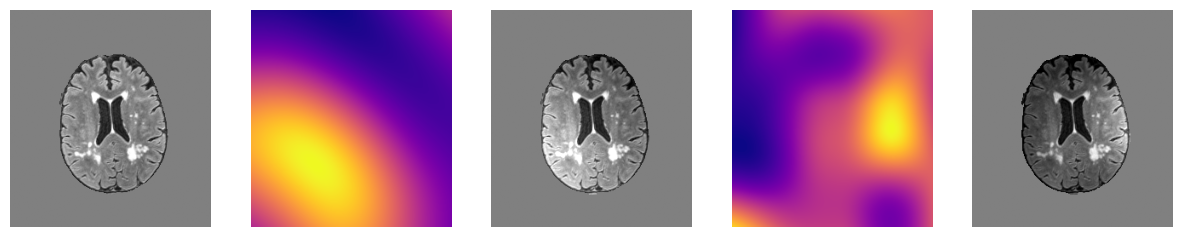

In [72]:
fig, axs = plt.subplots(1, 5, figsize=(15, 3))

axs[0].imshow(flair[islice], origin='lower', cmap='gray', vmin=-3, vmax=3)
axs[1].imshow(bf1[islice], origin='lower', cmap='plasma')
axs[2].imshow(img1[islice], origin='lower', cmap='gray', vmin=-3, vmax=3)
axs[3].imshow(bf2[islice], origin='lower', cmap='plasma')
axs[4].imshow(img2[islice], origin='lower', cmap='gray', vmin=-3, vmax=3)
for ax in axs:
    ax.axis('off')

### example of full augmentation pipeline

In [8]:
from synthnormaug import get_augmentation_pipeline

In [9]:
aug_pipeline = get_augmentation_pipeline(
    image_keys=['FLAIR'],
    label_keys=['label', 'brainmask'],
    out_spatial_dims=shape,
    gmm_weight_path=gmm_weight_path
)

In [39]:
full_pipeline_example1 = aug_pipeline(data)
full_pipeline_example2 = aug_pipeline(data)
full_pipeline_example3 = aug_pipeline(data)
full_pipeline_example4 = aug_pipeline(data)

augmented_flair1 = full_pipeline_example1[0][0]
augmented_wmh1 = full_pipeline_example1[1][0]
augmented_flair2 = full_pipeline_example2[0][0]
augmented_wmh2 = full_pipeline_example2[1][0]
augmented_flair3 = full_pipeline_example3[0][0]
augmented_wmh3 = full_pipeline_example3[1][0]
augmented_flair4 = full_pipeline_example4[0][0]
augmented_wmh4 = full_pipeline_example4[1][0]

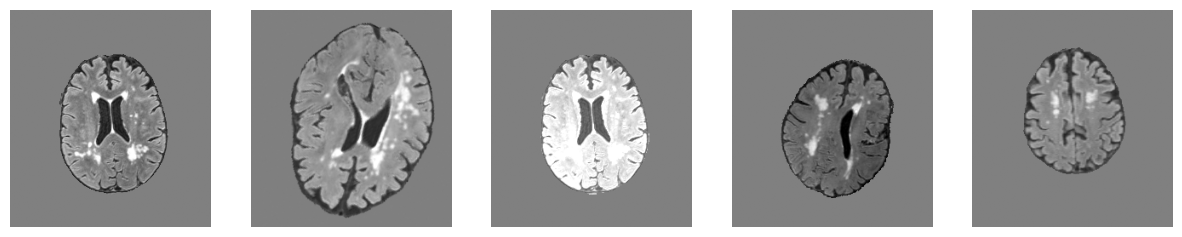

In [40]:
fig, axs = plt.subplots(1, 5, figsize=(15, 3))

axs[0].imshow(flair[islice], origin='lower', cmap='gray', vmin=-3, vmax=3)
axs[1].imshow(augmented_flair1[islice], origin='lower', cmap='gray', vmin=-3, vmax=3)
axs[2].imshow(augmented_flair2[islice], origin='lower', cmap='gray', vmin=-3, vmax=3)
axs[3].imshow(augmented_flair3[islice], origin='lower', cmap='gray', vmin=-3, vmax=3)
axs[4].imshow(augmented_flair4[islice], origin='lower', cmap='gray', vmin=-3, vmax=3)
for ax in axs:
    ax.axis('off')

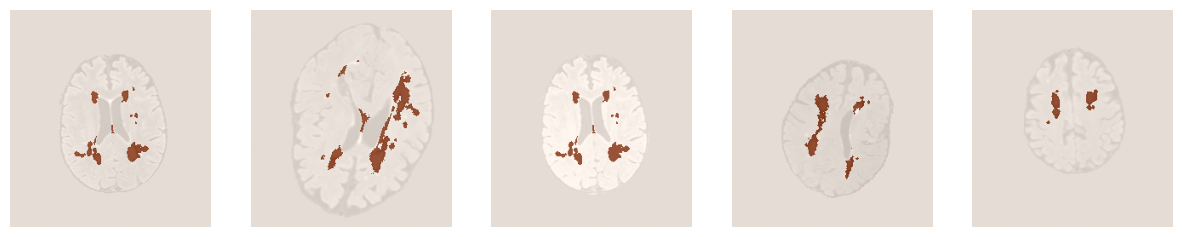

In [43]:
fig, axs = plt.subplots(1, 5, figsize=(15, 3))

axs[0].imshow(flair[islice], origin='lower', cmap='gray', vmin=-3, vmax=3)
axs[0].imshow(wmh[islice], origin='lower', cmap='Oranges', alpha=0.8)
axs[1].imshow(augmented_flair1[islice], origin='lower', cmap='gray', vmin=-3, vmax=3)
axs[1].imshow(augmented_wmh1[islice], origin='lower', cmap='Oranges', alpha=0.8)
axs[2].imshow(augmented_flair2[islice], origin='lower', cmap='gray', vmin=-3, vmax=3)
axs[2].imshow(augmented_wmh2[islice], origin='lower', cmap='Oranges', alpha=0.8)
axs[3].imshow(augmented_flair3[islice], origin='lower', cmap='gray', vmin=-3, vmax=3)
axs[3].imshow(augmented_wmh3[islice], origin='lower', cmap='Oranges', alpha=0.8)
axs[4].imshow(augmented_flair4[islice], origin='lower', cmap='gray', vmin=-3, vmax=3)
axs[4].imshow(augmented_wmh4[islice], origin='lower', cmap='Oranges', alpha=0.8)
for ax in axs:
    ax.axis('off')